In [1]:
!pip install requests
!pip install tensorflow
%tensorflow_version 2.x
import json
import requests
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, Dropout, LSTM
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [19]:
endpoint="https://min-api.cryptocompare.com/data/histoday"
res=requests.get(endpoint + "?fsym=BTC&tsym=CAD&limit=500")
hist=pd.DataFrame(json.loads(res.content)['Data'])
hist=hist.set_index('time')
hist.index=pd.to_datetime(hist.index, unit='s')
# Convert relevant columns to numeric, coercing errors to NaN
hist['high'] = pd.to_numeric(hist['high'], errors='coerce')
hist['low'] = pd.to_numeric(hist['low'], errors='coerce')
hist['open'] = pd.to_numeric(hist['open'], errors='coerce')
hist['volumefrom'] = pd.to_numeric(hist['volumefrom'], errors='coerce')
hist['volumeto'] = pd.to_numeric(hist['volumeto'], errors='coerce')
hist['close'] = pd.to_numeric(hist['close'], errors='coerce')
# Fill any NaN values that might have resulted from coercion, e.g., with 0 or the mean
hist = hist.fillna(0) # Or hist.fillna(hist.mean()) depending on desired behavior
target_col='close'

In [3]:
hist.head(5)

,high,low,open,volumefrom,volumeto,close,conversionType,conversionSymbol
time,,,,,,,,
2024-11-09,106364.60,104938.3,106222.9,8.933,944376.14,106160.20,direct,
2024-11-10,112300.00,106092.4,106160.2,31.610,3458160.13,111181.30,direct,
2024-11-11,119850.00,110899.5,111181.3,59.750,6926090.95,119400.00,direct,
2024-11-12,124787.30,106000.0,119400.0,84.970,10057075.44,121999.90,direct,
2024-11-13,129908.62,119233.9,121999.9,82.780,10397257.49,126011.82,direct,


In [6]:
def train_test_split(df, test_size=0.2):
  split_row=len(df)-int(test_size*len(df))
  train_data=df.iloc[:split_row]
  test_data=df.iloc[split_row:]
  return train_data, test_data

In [7]:
train, test= train_test_split(hist, test_size=0.2)

In [8]:
def line_plot(line1, line2, label1=None, label2=None, title='', lw=2):
  fig, ax=plt.subplots(1, figsize=(13, 7))
  ax.plot(line1, label=label1, linewidth=lw)
  ax.plot(line2, label=label2, linewidth=lw)
  ax.set_ylabel('price [CAD]', fontsize=14)
  ax.set_title(title, fontsize=16)
  ax.legend(loc='best', fontsize=16)

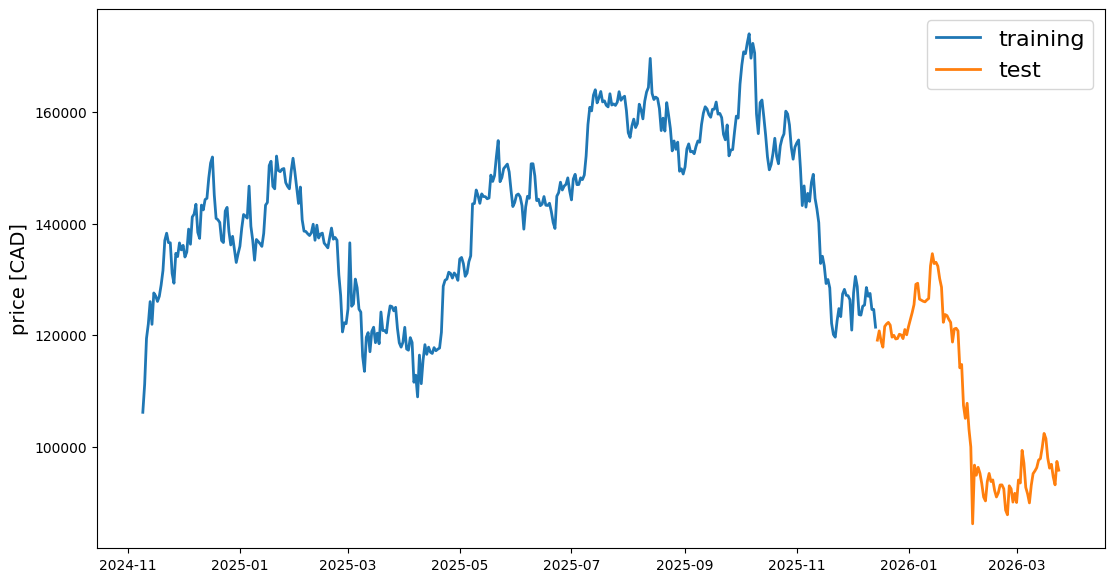

In [9]:
line_plot(train[target_col], test[target_col], 'training', 'test', title='')

In [11]:
def normalise_zero_base(df):
  return df/df.iloc[0]-1
def normalise_min_max(df):
  return (df-df.min())/(df.max()-df.min())

In [17]:
def extract_window_data(df, window_len=5, should_normalize=False):
  window_data=[]
  for idx in range(len(df)-window_len):
    tmp=df[idx:(idx+window_len)].copy()
    if should_normalize:
      tmp=normalise_zero_base(tmp)
    window_data.append(tmp.values)
  return np.array(window_data)

In [24]:
def prepare_data(df, target_col, window_len=10, zero_base=True, test_size=0.2):

    train_data, test_data = train_test_split(df, test_size=test_size)

    # Explicitly ensure target_col in train_data and test_data are numeric
    train_data[target_col] = pd.to_numeric(train_data[target_col], errors='coerce').fillna(0)
    test_data[target_col] = pd.to_numeric(test_data[target_col], errors='coerce').fillna(0)

    # Pass only the target column series to extract_window_data
    X_train = extract_window_data(train_data[target_col], window_len, zero_base)
    X_test = extract_window_data(test_data[target_col], window_len, zero_base)

    # Reshape X_train and X_test to be 3D for LSTM (samples, timesteps, features)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    y_train = train_data[target_col][window_len:].values
    y_test = test_data[target_col][window_len:].values

    if zero_base:
        y_train = y_train / train_data[target_col][:-window_len].values - 1
        y_test = y_test / test_data[target_col][:-window_len].values - 1

    return train_data, test_data, X_train, X_test, y_train, y_test

In [14]:
def build_lstm_model(input_data, output_size, neurons=100, activ_func='linear',
                     dropout=0.2, loss='mse', optimizer='adam'):

    model = Sequential()

    model.add(LSTM(neurons, input_shape=(input_data.shape[1], input_data.shape[2])))
    model.add(Dropout(dropout))
    model.add(Dense(units=output_size))
    model.add(Activation(activ_func))

    model.compile(loss=loss, optimizer=optimizer)
    return model


In [15]:
np.random.seed(42)
window_len = 5
test_size = 0.2
zero_base = True
lstm_neurons = 100
epochs = 20
batch_size = 32
loss = 'mse'
dropout = 0.2
optimizer = 'adam'

In [22]:
train, test, X_train, X_test, y_train, y_test=prepare_data(
    hist, target_col, window_len=window_len, zero_base=zero_base, test_size=test_size
)

/tmp/ipykernel_4939/1008449065.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[target_col] = pd.to_numeric(train_data[target_col], errors='coerce').fillna(0)
/tmp/ipykernel_4939/1008449065.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data[target_col] = pd.to_numeric(test_data[target_col], errors='coerce').fillna(0)


In [25]:
from IPython.core import history

# Ensure X_train has the correct 3D shape (samples, timesteps, features)
# This is a defensive step in case X_train was not correctly reshaped earlier or got reset.
if X_train.ndim == 2:
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

model = build_lstm_model(
    X_train, output_size=1, neurons=lstm_neurons, dropout=dropout, loss=loss,
    optimizer=optimizer)
history = model.fit(
    X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1, shuffle=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0020
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0016
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.1986e-04
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.1244e-04
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.0389e-04
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.3725e-04
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.7752e-04
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.4837e-04
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.1902e-04
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.0363e-04
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.5706e-04
Epoch 13/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.3182e-04
Epoch 14/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.3977e-04
Epoch 15/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0

In [27]:
targets=test[target_col][window_len:]
preds=model.predict(X_test).squeeze()
mean_absolute_error(prends, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


0.020698940248298735

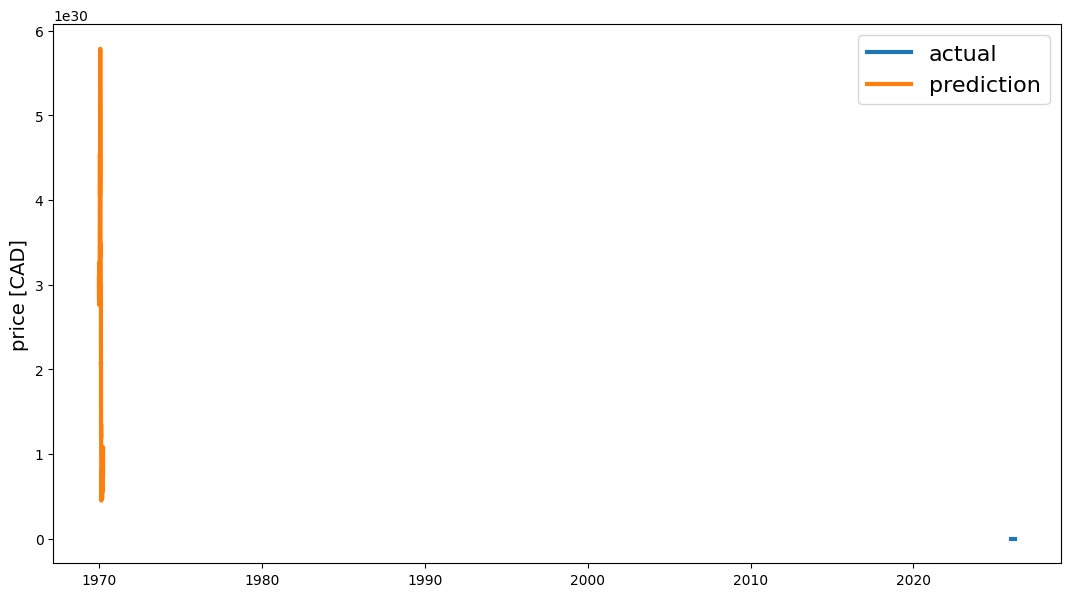

In [34]:
preds=test[target_col].values[:-window_len]*(preds+1)
perds=pd.Series(index=targets.index, data=preds)
line_plot(targets, preds, 'actual','prediction', lw=3)